#### Importing necessary libraries:--

In [1]:
### Step 1: Import Required Libraries
import pandas as pd  # For data manipulation
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For advanced visualizations
from sklearn.model_selection import train_test_split  # For splitting dataset
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding categorical data & scaling
from sklearn.cluster import KMeans, AgglomerativeClustering  # Clustering algorithms
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import catboost as cb
from wordcloud import WordCloud
import re  # For text cleaning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [7]:
import warnings
warnings.filterwarnings('ignore')

#### Reading Clean Files:--

In [357]:
df2 = pd.read_excel(r"C:\Users\HARSH\Ireland_Hotel_Bookings_ModelData.xlsx")

In [358]:
df2.head(3)

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,1409,1,2,1,1,169.283312,1
1,12,8.4,11452,1,2,1,1,109.405212,1
2,79,8.6,8672,1,2,0,0,114.880202,2


In [285]:
df2.drop(['Rating'],axis=1,inplace=True)

In [83]:
df3 = pd.read_excel(r"C:\Users\HARSH\Ireland_Hotel_Bookings_NLPData.xlsx")

In [84]:
df3.head(3)

,Y,X
0,1,"Sea Views from Select Rooms, Shared Lounge and..."
1,1,"Award-Winning Spa Experience, Family-Friendly Fun"
2,2,"River Liffey Views, Family-Friendly Rooms"


#### Traditional Model Building:--

In [359]:
df2.head()

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,1409,1,2,1,1,169.283312,1
1,12,8.4,11452,1,2,1,1,109.405212,1
2,79,8.6,8672,1,2,0,0,114.880202,2
3,114,9.1,6922,1,5,1,2,236.538462,2
4,62,8.5,3753,1,2,1,1,148.192518,2


#### Data Preprocessing

In [360]:
# # Apply Log Transformation to Booking_Price
# df2['Booking_Price'] = np.log1p(df2['Booking_Price'])

In [361]:
scaler = StandardScaler()  # Initialize StandardScaler
numerical_cols = ['Booking_Price', 'Total_Ratings']  # Select numerical columns
df2[numerical_cols] = scaler.fit_transform(df2[numerical_cols])  # Apply standardization

In [362]:
df2.head()

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,-0.460080,1,2,1,1,0.303453,1
1,12,8.4,1.992614,1,2,1,1,-0.588324,1
2,79,8.6,1.313684,1,2,0,0,-0.506784,2
3,114,9.1,0.886301,1,5,1,2,1.305099,2
4,62,8.5,0.112370,1,2,1,1,-0.010656,2


In [363]:
# check for class imbalance:-

df2.Rating_Category.value_counts()    # Heavily Class Imbalance in data



2    704
1    260
0     76
Name: Rating_Category, dtype: int64

In [364]:
df2.shape

(1040, 9)

In [365]:
# # feature imp line:-
# df2 = df2.loc[:,l1_rfc]

In [366]:
# # feature imp line:-
# df2 = df2.loc[:,l1_dt]

#### Sampling

In [367]:
df2_train , df2_test = train_test_split(df2, test_size=0.20)

df2_train_x = df2_train.drop(['Rating_Category'],axis=1)
df2_train_y = df2_train.Rating_Category


df2_test_x = df2_test.drop(['Rating_Category'],axis=1)
df2_test_y = df2_test.Rating_Category

In [368]:
df2_train_x.shape

(832, 8)

In [369]:
df2_train_y.value_counts()

2    557
1    212
0     63
Name: Rating_Category, dtype: int64

In [370]:
from imblearn.over_sampling import SMOTE

In [371]:
smote = SMOTE(random_state=42)  # Initialize SMOTE

In [372]:
df2_train_x_resampled , df2_train_y_resampled =smote.fit_resample(df2_train_x , df2_train_y)

In [373]:
df2_train_x_resampled.shape

(1671, 8)

In [374]:
df2_train_y_resampled.value_counts()

2    557
1    557
0    557
Name: Rating_Category, dtype: int64

In [375]:
# Now we will train the models on smote_resampled data

In [376]:
df2_test_y.value_counts()

2    147
1     48
0     13
Name: Rating_Category, dtype: int64

#### Model Building Stage:--

#### Logistic Regression:--

In [24]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(df2_train_x_resampled , df2_train_y_resampled)
pred_logreg = logreg.predict(df2_test_x)

In [25]:
from sklearn.metrics import *

In [26]:
# building confusion matrix :--

tab_logreg = confusion_matrix(df2_test_y , pred_logreg)
tab_logreg = pd.DataFrame(tab_logreg)
tab_logreg.columns = ['Good' , 'Very_Good','Excellent']
tab_logreg.index =['Good' , 'Very_Good','Excellent']
tab_logreg

,Good,Very_Good,Excellent
Good,18,0,0
Very_Good,3,54,1
Excellent,0,3,129


In [27]:
print(classification_report(df2_test_y , pred_logreg))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        18
           1       0.95      0.93      0.94        58
           2       0.99      0.98      0.98       132

    accuracy                           0.97       208
   macro avg       0.93      0.97      0.95       208
weighted avg       0.97      0.97      0.97       208



#### Decision Tree :--

In [143]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight='balanced', criterion='gini' , max_depth=5 , min_samples_split=25, ccp_alpha=0.01)

In [144]:
dt.fit(df2_train_x_resampled ,df2_train_y_resampled)

DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced', max_depth=5,
                       min_samples_split=25)

In [29]:
#from sklearn.model_selection import GridSearchCV

In [30]:
# search_dict = {'criterion':['gini','entropy'] , 
#                'max_depth':range(5,100) , 
#                 'min_samples_split':range(25,30)}

In [31]:
#grid = GridSearchCV(dt , param_grid=search_dict)

In [32]:
#grid.fit(df2_train_x_resampled , df2_train_y_resampled)

GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced'),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(5, 100),
                         'min_samples_split': range(25, 30)})

In [33]:
#grid.best_params_ 

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 25}

In [145]:
pred_test_dt = dt.predict(df2_test_x)

In [146]:
# building confusion matrix :--

tab_dt = confusion_matrix(df2_test_y , pred_test_dt)
tab_dt = pd.DataFrame(tab_dt)
tab_dt.columns = ['Good' , 'Very_Good','Excellent']
tab_dt.index =['Good' , 'Very_Good','Excellent']
tab_dt

,Good,Very_Good,Excellent
Good,6,9,6
Very_Good,6,35,13
Excellent,14,60,59


In [147]:
print(classification_report(df2_test_y , pred_test_dt))

              precision    recall  f1-score   support

           0       0.23      0.29      0.26        21
           1       0.34      0.65      0.44        54
           2       0.76      0.44      0.56       133

    accuracy                           0.48       208
   macro avg       0.44      0.46      0.42       208
weighted avg       0.59      0.48      0.50       208



In [129]:
from sklearn.model_selection import cross_val_score

dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
scores = cross_val_score(dt_model, df2_train_x_resampled, df2_train_y_resampled, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy:", scores.mean())



Cross-Validation Accuracy: 0.5470879497129212


In [130]:
feat_imp_dt = pd.DataFrame()
feat_imp_dt['features'] = df2_train_x_resampled.columns
feat_imp_dt['imp'] = dt.feature_importances_
feat_imp_dt = feat_imp_dt.sort_values('imp',ascending=False)
feat_imp_dt

,features,imp
6,Booking_Price,0.532249
1,Total_Ratings,0.313744
0,City,0.154006
2,Discount_Price_Tag,0.000000
3,website,0.000000
4,Benefits,0.000000
5,Benefits_2,0.000000


In [131]:
l1_dt = list(feat_imp_dt.features[0:3])
l1_dt.append('Rating_Category')
l1_dt

['Booking_Price', 'Total_Ratings', 'City', 'Rating_Category']

In [49]:
# Decison Tree overfitted

#### Random Forest:--

In [184]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(class_weight='balanced',n_estimators=100, max_depth=5, random_state=42)

In [185]:
rfc.fit(df2_train_x_resampled , df2_train_y_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [186]:
pred_rfc = rfc.predict(df2_test_x)

In [187]:
tab_rfc = confusion_matrix(df2_test_y , pred_rfc)
tab_rfc = pd.DataFrame(tab_rfc )
tab_rfc.columns =['Good' , 'Very_Good','Excellent']
tab_rfc.index = ['Good' , 'Very_Good','Excellent']
tab_rfc

,Good,Very_Good,Excellent
Good,4,7,6
Very_Good,11,16,19
Excellent,23,44,78


In [188]:
print(classification_report(df2_test_y , pred_rfc ))

              precision    recall  f1-score   support

           0       0.11      0.24      0.15        17
           1       0.24      0.35      0.28        46
           2       0.76      0.54      0.63       145

    accuracy                           0.47       208
   macro avg       0.37      0.37      0.35       208
weighted avg       0.59      0.47      0.51       208



In [171]:
feat_imp_rfc = pd.DataFrame()
feat_imp_rfc['features'] = df2_train_x.columns
feat_imp_rfc['imp'] = rfc.feature_importances_
feat_imp_rfc = feat_imp_rfc.sort_values('imp',ascending=False)
feat_imp_rfc

,features,imp
6,Booking_Price,0.400589
1,Total_Ratings,0.253138
0,City,0.186469
5,Benefits_2,0.066211
3,website,0.051503
4,Benefits,0.041277
2,Discount_Price_Tag,0.000813


In [172]:
l1_rfc = list(feat_imp_rfc.features[0:3])
l1_rfc.append('Rating_Category')
l1_rfc

['Booking_Price', 'Total_Ratings', 'City', 'Rating_Category']

#### XGBOOST Classifier model building

In [189]:
import xgboost

In [190]:
from xgboost import XGBClassifier
xgbc = XGBClassifier()
xgbc.fit(df2_train_x_resampled , df2_train_y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [191]:
pred_xgbc = xgbc.predict(df2_test_x)

In [192]:
# building confusion matrix :--

tab_xgbc = confusion_matrix(df2_test_y , pred_xgbc)
tab_xgbc= pd.DataFrame(tab_xgbc)
tab_xgbc.columns = ['Good' , 'Very_Good','Excellent' ]
tab_xgbc.index =['Good' , 'Very_Good','Excellent']
tab_xgbc

,Good,Very_Good,Excellent
Good,3,7,7
Very_Good,10,14,22
Excellent,19,31,95


In [193]:
print(classification_report(df2_test_y , pred_xgbc))

              precision    recall  f1-score   support

           0       0.09      0.18      0.12        17
           1       0.27      0.30      0.29        46
           2       0.77      0.66      0.71       145

    accuracy                           0.54       208
   macro avg       0.38      0.38      0.37       208
weighted avg       0.60      0.54      0.57       208



#### Naive Bayes :--

In [253]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(df2_train_x_resampled ,df2_train_y_resampled)

MultinomialNB()

In [254]:
pred_nb = nb.predict(df2_test_x)

In [255]:
# building confusion matrix :--

tab_nb = confusion_matrix(df2_test_y , pred_nb)
tab_nb = pd.DataFrame(tab_nb)
tab_nb.columns = ['Good' , 'Very_Good','Excellent' ]
tab_nb.index =['Good' , 'Very_Good','Excellent'  ]
tab_nb

,Good,Very_Good,Excellent
Good,0,4,9
Very_Good,6,27,25
Excellent,3,36,98


In [256]:
print(classification_report(df2_test_y , pred_nb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.40      0.47      0.43        58
           2       0.74      0.72      0.73       137

    accuracy                           0.60       208
   macro avg       0.38      0.39      0.39       208
weighted avg       0.60      0.60      0.60       208



#### KNN:--

In [300]:
df2.head(3)

,City,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,-0.460080,1,2,1,1,0.303453,1
1,12,1.992614,1,2,1,1,-0.588324,1
2,79,1.313684,1,2,0,0,-0.506784,2


In [301]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(df2_train_x_resampled,df2_train_y_resampled)

KNeighborsClassifier()

In [302]:
pred_knn = knn.predict(df2_test_x)

In [303]:
# building confusion matrix :--

tab_knn = confusion_matrix(df2_test_y , pred_knn)
tab_knn = pd.DataFrame(tab_knn)
tab_knn.columns = ['Good' , 'Very_Good','Excellent' ]
tab_knn.index =['Good' , 'Very_Good','Excellent' ]
tab_knn

,Good,Very_Good,Excellent
Good,5,9,2
Very_Good,22,16,19
Excellent,40,38,57


In [304]:
print(classification_report(df2_test_y , pred_knn))

              precision    recall  f1-score   support

           0       0.07      0.31      0.12        16
           1       0.25      0.28      0.27        57
           2       0.73      0.42      0.54       135

    accuracy                           0.38       208
   macro avg       0.35      0.34      0.31       208
weighted avg       0.55      0.38      0.43       208



In [305]:
# code for graph to find the value of neighbors:-

In [306]:
acc = []
for k in range(1,51):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(df2_train_x_resampled , df2_train_y_resampled)
    pred_knn = knn.predict(df2_test_x)
    tab_knn = confusion_matrix(df2_test_y, pred_knn)
    acc.append(tab_knn.diagonal().sum()/ tab_knn.sum())
#     print(k)

In [307]:
l1 = list(range(1,51))

Text(0, 0.5, 'Accuracy')

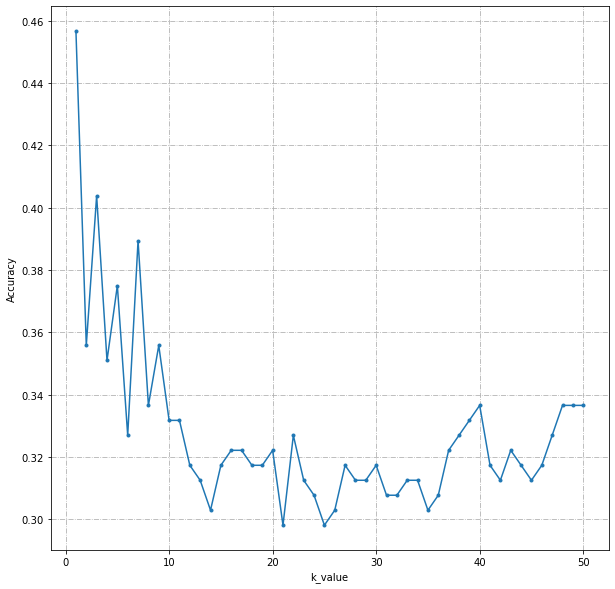

In [308]:
plt.figure(figsize=(10,10))
plt.plot(l1 , acc , marker = '.')
plt.grid(linestyle='-.')
plt.xlabel('k_value')
plt.ylabel('Accuracy')

#### SVM:--

In [377]:
df2.head(3)

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,-0.460080,1,2,1,1,0.303453,1
1,12,8.4,1.992614,1,2,1,1,-0.588324,1
2,79,8.6,1.313684,1,2,0,0,-0.506784,2


In [378]:
from sklearn.svm import SVC
svc= SVC(class_weight='balanced', kernel='linear')
svc.fit(df2_train_x_resampled , df2_train_y_resampled)
pred_svc = svc.predict(df2_test_x)

In [379]:
# building confusion matrix :--

tab_svc = confusion_matrix(df2_test_y , pred_svc)
tab_svc = pd.DataFrame(tab_svc)
tab_svc.columns = ['Good' , 'Very_Good','Excellent' ]
tab_svc.index =['Good' , 'Very_Good','Excellent' ]
tab_svc

,Good,Very_Good,Excellent
Good,13,0,0
Very_Good,5,43,0
Excellent,0,3,144


In [380]:
print(classification_report(df2_test_y , pred_svc))

              precision    recall  f1-score   support

           0       0.72      1.00      0.84        13
           1       0.93      0.90      0.91        48
           2       1.00      0.98      0.99       147

    accuracy                           0.96       208
   macro avg       0.89      0.96      0.91       208
weighted avg       0.97      0.96      0.96       208



In [381]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

#### Ensemble SVC :--

In [418]:
# keeping rating columns

In [382]:


ensemble_svm = BaggingClassifier(base_estimator=SVC(kernel='linear'), n_estimators=10, random_state=42)
ensemble_svm.fit(df2_train_x_resampled , df2_train_y_resampled)


BaggingClassifier(base_estimator=SVC(kernel='linear'), random_state=42)

In [383]:
pred_ensemble_svc = ensemble_svm.predict(df2_test_x)

In [384]:
# building confusion matrix :--

tab_ensemble_svc = confusion_matrix(df2_test_y , pred_ensemble_svc)
tab_ensemble_svc  = pd.DataFrame(tab_ensemble_svc )
tab_ensemble_svc .columns = ['Good' , 'Very_Good','Excellent' ]
tab_ensemble_svc .index =['Good' , 'Very_Good','Excellent' ]
tab_ensemble_svc 

,Good,Very_Good,Excellent
Good,13,0,0
Very_Good,5,43,0
Excellent,0,5,142


In [386]:
print(classification_report(df2_test_y ,pred_ensemble_svc ))

              precision    recall  f1-score   support

           0       0.72      1.00      0.84        13
           1       0.90      0.90      0.90        48
           2       1.00      0.97      0.98       147

    accuracy                           0.95       208
   macro avg       0.87      0.95      0.91       208
weighted avg       0.96      0.95      0.95       208



#### General Analysis comparing mean of booking prices for different rating hotels

In [444]:
df2 = pd.read_excel(r"C:\Users\HARSH\Ireland_Hotel_Bookings_ModelData.xlsx")

In [445]:
df2.head(3)

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,1409,1,2,1,1,169.283312,1
1,12,8.4,11452,1,2,1,1,109.405212,1
2,79,8.6,8672,1,2,0,0,114.880202,2


In [446]:
df2.columns

Index(['City', 'Rating', 'Total_Ratings', 'Discount_Price_Tag', 'website',
       'Benefits', 'Benefits_2', 'Booking_Price', 'Rating_Category'],
      dtype='object')

In [447]:
df2GoodData = df2[df2['Rating_Category'] == 0]
df2GoodData.head()

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
25,73,7.9,6098,1,2,2,2,159.678436,0
51,79,7.9,4498,1,2,1,0,134.268600,0
85,201,7.7,6473,1,2,1,1,88.514082,0
125,160,7.9,3489,1,2,1,1,159.131988,0
132,200,7.9,5448,1,2,1,0,117.360235,0


In [449]:
df2GoodData['Booking_Price'].mean() # Average booking price for Good Hotels

121.94683192849716

In [450]:
df2VeryGoodData = df2[df2['Rating_Category'] == 1]
df2VeryGoodData .head()

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
0,35,8.2,1409,1,2,1,1,169.283312,1
1,12,8.4,11452,1,2,1,1,109.405212,1
6,79,8.3,8233,1,2,2,2,142.118537,1
8,166,8.3,5420,1,2,1,1,113.387978,1
12,103,8.3,3970,1,2,1,2,103.436318,1


In [451]:
df2VeryGoodData['Booking_Price'].mean() # Average booking price for Very Good Hotels

136.86968506483024

In [454]:
df2ExcellentData = df2[df2['Rating_Category'] == 2]
df2ExcellentData .head()

,City,Rating,Total_Ratings,Discount_Price_Tag,website,Benefits,Benefits_2,Booking_Price,Rating_Category
2,79,8.6,8672,1,2,0,0,114.880202,2
3,114,9.1,6922,1,5,1,2,236.538462,2
4,62,8.5,3753,1,2,1,1,148.192518,2
5,201,8.6,11899,1,2,1,1,100.451871,2
7,12,8.9,12301,1,2,1,1,99.464061,2


In [457]:
df2ExcellentData['Booking_Price'].mean() # Average booking price for Excellent Hotels

156.2645986185945

#### NLP Model Building :--

In [474]:
df3 = pd.read_excel(r"C:\Users\HARSH\Ireland_Hotel_Bookings_NLPData.xlsx")

In [475]:
df3.head()

,Y,X
0,1,"Sea Views from Select Rooms, Shared Lounge and..."
1,1,"Award-Winning Spa Experience, Family-Friendly Fun"
2,2,"River Liffey Views, Family-Friendly Rooms"
3,2,"Beautiful Garden Views, Live Music"
4,2,"On-site Restaurant & Bar, Kids' Paradise"


In [476]:
df3.isnull().sum()

Y    0
X    0
dtype: int64

In [477]:
df3.shape

(1040, 2)

In [478]:
df3.Y.value_counts()

2    704
1    260
0     76
Name: Y, dtype: int64

#### Data Cleaning:--

In [479]:
# now lets convert text in lower case since python is a case sensitive language:-
df3.X = df3.X.str.lower() # Mandtory

In [480]:
df3.head()

,Y,X
0,1,"sea views from select rooms, shared lounge and..."
1,1,"award-winning spa experience, family-friendly fun"
2,2,"river liffey views, family-friendly rooms"
3,2,"beautiful garden views, live music"
4,2,"on-site restaurant & bar, kids' paradise"


In [481]:
# check for stopwords:-

In [482]:
import nltk # nltk - natural language toolkit

In [483]:
from nltk.corpus import stopwords

In [484]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [485]:
l1 = stopwords.words("english")

In [486]:
# UDF code :-

In [487]:
def text_process(mess):            ### creating a function

    """                                                        ## a docstring

    1. remove the punctuation

    2. remove the stopwords

    3. return the list of clean textwords

    

    """

    nopunc = [char for char in mess if char not in string.punctuation]

    nopunc = "".join(nopunc)

    

    return [ word for word in nopunc.split() if word not in l1]

In [488]:
from sklearn.feature_extraction.text import CountVectorizer

In [489]:
bow_transformer = CountVectorizer(analyzer = text_process).fit(df3["X"])

In [490]:
bow_transformer.vocabulary_

{'sea': 595,
 'views': 751,
 'select': 600,
 'rooms': 580,
 'shared': 610,
 'lounge': 415,
 'terrace': 681,
 'awardwinning': 53,
 'spa': 633,
 'experience': 250,
 'familyfriendly': 264,
 'fun': 288,
 'river': 571,
 'liffey': 403,
 'beautiful': 74,
 'garden': 294,
 'live': 407,
 'music': 453,
 'onsite': 477,
 'restaurant': 562,
 'bar': 63,
 'kids': 384,
 'paradise': 495,
 'indoor': 359,
 'pool': 520,
 'relaxation': 556,
 'local': 410,
 'art': 40,
 'historic': 341,
 'charm': 126,
 'grand': 312,
 'canal': 105,
 'fitness': 279,
 'centre': 121,
 'recreation': 546,
 'exceptional': 248,
 'great': 313,
 'families': 262,
 'groups': 317,
 'zest': 786,
 'health': 328,
 'club': 144,
 'sauna': 590,
 'steam': 653,
 'room': 579,
 'perfect': 504,
 'special': 637,
 'occasions': 469,
 'manor': 428,
 'house': 353,
 'setting': 607,
 'championship': 122,
 'golf': 305,
 'course': 171,
 'upscale': 739,
 'center': 119,
 'riverfront': 572,
 'luxury': 420,
 'rejuvenate': 554,
 'treatment': 715,
 'leisure': 400,

In [491]:
# Create a TDM

In [492]:
tdm = bow_transformer.transform(df3.X)

In [493]:
tdm.shape

(1040, 788)

In [494]:
# tdm will act as our X while sampling stage - using tdm we will build the model:--

#### Sampling Stage in NLP :--

In [496]:
from sklearn.model_selection import train_test_split

In [602]:
df3.Y.value_counts() # Class Imbalance

2    704
1    260
0     76
Name: Y, dtype: int64

In [603]:
df3.shape

(1040, 2)

In [497]:
train_X  , test_X , train_Y  , test_Y = train_test_split(tdm , df3.Y , test_size = .20)

In [ ]:
# # oversampling stage:-
# df_OS_1 = df3.Y[df3.Y == 1]
# md_train = pd.concat([md_train , df1 ,df1,df1,df1,df1 ,df1,df1,df1,df1,df1,df1,df1,df1])

#### model building stage:--

#### NAIVE BAYES

In [498]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(train_X , train_Y)

MultinomialNB()

In [499]:
nb_pred = nb.predict(test_X)
nb_pred

array([2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 2, 1, 2, 2, 1, 2, 2, 2], dtype=int64)

In [501]:
tab_nb = confusion_matrix(test_Y , nb_pred)
tab_nb = pd.DataFrame(tab_nb)
tab_nb.columns = ['Good','Very Good','Excellent']
tab_nb.index = ['Good','Very Good','Excellent']
tab_nb

,Good,Very Good,Excellent
Good,0,1,8
Very Good,0,6,41
Excellent,6,16,130


In [502]:
print(classification_report(test_Y , nb_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.26      0.13      0.17        47
           2       0.73      0.86      0.79       152

    accuracy                           0.65       208
   macro avg       0.33      0.33      0.32       208
weighted avg       0.59      0.65      0.61       208



#### Logistic Regression Model :-

In [503]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(train_X , train_Y)
pred_logreg = logreg.predict(test_X)

In [504]:
tab_logreg = confusion_matrix(test_Y , pred_logreg)
tab_logreg  = pd.DataFrame(tab_logreg )
tab_logreg .columns = ['Good','Very Good','Excellent']
tab_logreg .index = ['Good','Very Good','Excellent']
tab_logreg 

,Good,Very Good,Excellent
Good,2,1,6
Very Good,6,15,26
Excellent,12,34,106


In [505]:
print(classification_report(test_Y , pred_logreg))

              precision    recall  f1-score   support

           0       0.10      0.22      0.14         9
           1       0.30      0.32      0.31        47
           2       0.77      0.70      0.73       152

    accuracy                           0.59       208
   macro avg       0.39      0.41      0.39       208
weighted avg       0.63      0.59      0.61       208



#### Building Decision Tree :--

In [ ]:
#'criterion': 'entropy', 'max_depth': 53, 'min_samples_split': 27

In [521]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight='balanced' , criterion='entropy',max_depth=53, min_samples_split=27)

In [522]:
dt.fit(train_X ,train_Y)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=53, min_samples_split=27)

In [523]:
pred_dt = dt.predict(test_X)

In [524]:
tab_dt = confusion_matrix(test_Y , pred_dt)
tab_dt  = pd.DataFrame(tab_dt )
tab_dt.columns = ['Good','Very Good','Excellent']
tab_dt .index = ['Good','Very Good','Excellent']
tab_dt 

,Good,Very Good,Excellent
Good,1,2,6
Very Good,6,25,16
Excellent,10,61,81


In [525]:
print(classification_report(test_Y , pred_dt))

              precision    recall  f1-score   support

           0       0.06      0.11      0.08         9
           1       0.28      0.53      0.37        47
           2       0.79      0.53      0.64       152

    accuracy                           0.51       208
   macro avg       0.38      0.39      0.36       208
weighted avg       0.64      0.51      0.55       208



In [516]:
# search_dict = {'criterion':['gini','entropy'] , 
#                'max_depth':range(5,100) , 
#                 'min_samples_split':range(25,30)}

In [518]:
#grid = GridSearchCV(dt , param_grid=search_dict)

In [519]:
#grid.fit(train_X ,train_Y)

GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced'),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(5, 100),
                         'min_samples_split': range(25, 30)})

In [520]:
#grid.best_params_ 

{'criterion': 'entropy', 'max_depth': 53, 'min_samples_split': 27}

#### Adaboost:

In [526]:
from sklearn.ensemble import AdaBoostClassifier
abc = AdaBoostClassifier(dt)

In [527]:
abc.fit(train_X,train_Y)


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    criterion='entropy',
                                                    max_depth=53,
                                                    min_samples_split=27))

In [528]:
pred_abc = abc.predict(test_X)

In [530]:
tab_abc = confusion_matrix(test_Y , pred_abc)
tab_abc = pd.DataFrame(tab_abc )
tab_abc.columns = ['Good','Very Good','Excellent']
tab_abc .index = ['Good','Very Good','Excellent']
tab_abc

,Good,Very Good,Excellent
Good,0,2,7
Very Good,1,12,34
Excellent,1,17,134


In [531]:
print(classification_report(test_Y , pred_abc))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.39      0.26      0.31        47
           2       0.77      0.88      0.82       152

    accuracy                           0.70       208
   macro avg       0.38      0.38      0.38       208
weighted avg       0.65      0.70      0.67       208



#### XGBoost Classifier :-

In [532]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

In [533]:
xgb.fit(train_X , train_Y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [534]:
pred_xgb = xgb.predict(test_X)

In [535]:
tab_xgb = confusion_matrix(test_Y , pred_xgb)
tab_xgb = pd.DataFrame(tab_xgb )
tab_xgb.columns = ['Good','Very Good','Excellent']
tab_xgb .index = ['Good','Very Good','Excellent']
tab_xgb

,Good,Very Good,Excellent
Good,0,2,7
Very Good,1,13,33
Excellent,0,15,137


In [536]:

print(classification_report(test_Y , pred_xgb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.43      0.28      0.34        47
           2       0.77      0.90      0.83       152

    accuracy                           0.72       208
   macro avg       0.40      0.39      0.39       208
weighted avg       0.66      0.72      0.68       208



#### Random Forest:---

In [ ]:
#max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

In [578]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(class_weight='balanced', n_estimators=100)

In [579]:
rfc.fit(train_X ,train_Y)

RandomForestClassifier(class_weight='balanced')

In [580]:
pred_rfc = rfc.predict(test_X)

In [581]:
tab_rfc = confusion_matrix(test_Y , pred_rfc)
tab_rfc = pd.DataFrame(tab_rfc )
tab_rfc.columns = ['Good','Very Good','Excellent']
tab_rfc.index = ['Good','Very Good','Excellent']
tab_rfc

,Good,Very Good,Excellent
Good,0,1,8
Very Good,0,5,42
Excellent,1,4,147


In [582]:
print(classification_report(test_Y , pred_rfc ))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.50      0.11      0.18        47
           2       0.75      0.97      0.84       152

    accuracy                           0.73       208
   macro avg       0.42      0.36      0.34       208
weighted avg       0.66      0.73      0.66       208



#### Hyper parameter tuning of Random Forest:--

In [569]:
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, None],  # Tree depth
    'min_samples_split': [2, 5, 10],  # Min samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Min samples in a leaf node
    'max_features': ['sqrt', 'log2']  # Number of features considered for best split
}

In [570]:
#Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(rfc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [571]:
grid_search.fit(train_X ,train_Y)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(class_weight='balanced'),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [572]:
#Get the Best Parameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


 #### SVM :-

In [564]:
from sklearn.svm import SVC
svc= SVC(class_weight='balanced', kernel='linear')

In [565]:
svc.fit(train_X ,train_Y)

SVC(class_weight='balanced', kernel='linear')

In [566]:
pred_svc = svc.predict(test_X)

In [567]:
tab_svc = confusion_matrix(test_Y , pred_svc)
tab_svc = pd.DataFrame(tab_svc)
tab_svc.columns = ['Good','Very Good','Excellent']
tab_svc.index = ['Good','Very Good','Excellent']
tab_svc

,Good,Very Good,Excellent
Good,2,0,7
Very Good,8,14,25
Excellent,12,36,104


In [568]:
print(classification_report(test_Y , pred_svc))



              precision    recall  f1-score   support

           0       0.09      0.22      0.13         9
           1       0.28      0.30      0.29        47
           2       0.76      0.68      0.72       152

    accuracy                           0.58       208
   macro avg       0.38      0.40      0.38       208
weighted avg       0.63      0.58      0.60       208



#### K Fold cross validation:--

In [583]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [584]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [585]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [586]:
# Evaluate using stratified cross-validation
scores = cross_val_score(model,train_X, train_Y, cv=skf, scoring='accuracy')

In [587]:
print("Stratified K-Fold Cross-Validation Accuracy:", scores.mean())

Stratified K-Fold Cross-Validation Accuracy: 0.6466488709328331


#### SMOTE technique for Over Sampling :--

In [588]:
from imblearn.over_sampling import SMOTE

In [589]:
# Apply SMOTE to Balance Training Data
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(train_X, train_Y)

In [593]:
# Train a Model with Balanced Data
rf_model = RandomForestClassifier(random_state=42 , n_estimators=100)
rf_model.fit(X_train_smote, Y_train_smote)

RandomForestClassifier(random_state=42)

In [594]:
# Predict on the Test Set (Which is Still Imbalanced)
y_pred = rf_model.predict(test_X)

In [595]:
# Evaluate Model Performance
print("Accuracy:", accuracy_score(test_Y, y_pred))
print("Classification Report:\n", classification_report(test_Y, y_pred))

Accuracy: 0.6057692307692307
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.33      0.49      0.40        47
           2       0.79      0.68      0.73       152

    accuracy                           0.61       208
   macro avg       0.38      0.39      0.38       208
weighted avg       0.65      0.61      0.62       208



In [596]:
from imblearn.combine import SMOTETomek

In [597]:
# Apply SMOTE + Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(train_X, train_Y)

In [598]:
# Train a Model with Balanced Data
rf_model = RandomForestClassifier(random_state=42 , n_estimators=100 , class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [599]:
# Predict on the Test Set (Which is Still Imbalanced)
y_pred_rf = rf_model.predict(test_X)

In [600]:
# Evaluate Model Performance
print("Accuracy:", accuracy_score(test_Y, y_pred_rf))
print("Classification Report:\n", classification_report(test_Y, y_pred_rf))

Accuracy: 0.6394230769230769
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.39      0.51      0.44        47
           2       0.80      0.72      0.76       152

    accuracy                           0.64       208
   macro avg       0.40      0.41      0.40       208
weighted avg       0.67      0.64      0.65       208

